In [ ]:
library(tidyverse)
library(Seurat)
library(patchwork)
library(tidyverse)
library(RColorBrewer)

In [ ]:
library(ggpubr)

In [3]:
GSC_merge_SCT_isct <- readRDS(file = 'GSC_merge_SCT_isct.Rds')

In [4]:
class(GSC_merge_SCT_isct[["Spatial"]])

[1] "Assay5"
attr(,"package")
[1] "SeuratObject"

In [5]:
GSC_merge_SCT_isct@meta.data$pos  %>% unique()

[1] "B7" "B4" "B1" "B8" "B5" "C7" "C4" "C9" "C6" "C3" "C8" "C5" "D7" "D4" "D9"
[16] "D5" "D2" "E7" "E4" "E9" "E8" "E5" "E6" "E2"

In [6]:
metadata <- GSC_merge_SCT_isct@meta.data 
metadata  %>% filter(!pos %in% c('B3','B6','C1','D8'))  %>% 
    rownames()  %>% GSC_merge_SCT_isct[,.] -> GSC_merge_SCT_isct2

In [7]:
GSC_merge_SCT_isct2

An object of class Seurat 
36161 features across 19529 samples within 2 assays 
Active assay: SCT (18076 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: Spatial
 4 images present: slice2, slice3, slice4, slice5

In [8]:
GSC_merge_SCT_isct2@meta.data[,c('pos','group')] -> GSC_merge_SCT_isct2@meta.data

In [9]:
GSC_merge_SCT_isct2@meta.data %>% rownames() %>% str_replace('GCA_spatial','xinpian')  %>% 
    str_split('_')  %>%   map_chr(~ paste0(.x[1],'_' ,.x[2])) -> rownames

In [10]:
colnames(GSC_merge_SCT_isct2) <- rownames

In [11]:
data <- read.table('Geneexpression_fromCell2location.txt',header=T)

In [12]:
spatial_celllocation <- read.table('Allmetafile_fromCell2location.txt',header=T)

In [13]:
rownames(spatial_celllocation) <- spatial_celllocation$spot_id

In [14]:
#GSC_merge_SCT_isct2@images[['slice4']] = NULL

In [15]:
colnames(GSC_merge_SCT_isct2@meta.data)  %>% str_replace('-','_') -> colnames(GSC_merge_SCT_isct2@meta.data) 

In [16]:
isct_names <- intersect(rownames,data$spot_id)

In [17]:
length(isct_names)

[1] 19529

In [18]:
GSC_merge_SCT_isct2[,isct_names] -> GSC_merge_SCT_isct2

In [19]:
GSC_merge_SCT_isct2$pos  %>% unique()  

[1] "B7" "B4" "B1" "B8" "B5" "C7" "C4" "C9" "C6" "C3" "C8" "C5" "D7" "D4" "D9"
[16] "D5" "D2" "E7" "E4" "E9" "E8" "E5" "E6" "E2"

In [20]:
GSC_merge_SCT_isct2@meta.data  %>% write.table(file="metadata.txt",sep="\t",row.names =T,quote=F)

In [21]:
rownames(data) <- data$spot_id

In [22]:
data[isct_names,] -> data2

In [23]:
colnames(spatial_celllocation)

[1] "spot_id"                     "in_tissue"                  
 [3] "array_row"                   "array_col"                  
 [5] "sample"                      "n_genes_by_counts"          
 [7] "log1p_n_genes_by_counts"     "total_counts"               
 [9] "log1p_total_counts"          "pct_counts_in_top_50_genes" 
[11] "pct_counts_in_top_100_genes" "pct_counts_in_top_200_genes"
[13] "pct_counts_in_top_500_genes" "mt_frac"                    
[15] "X_indices"                   "X_scvi_batch"               
[17] "X_scvi_labels"               "Bcell"                      
[19] "DendriticCells"              "Endothelial"                
[21] "Epi_normal"                  "Epi_tumor"                  
[23] "Fibroblasts"                 "Macrophages"                
[25] "Mastcell"                    "Monocytes"                  
[27] "Musclecell"                  "NKcell"                     
[29] "Neutrophils"                 "Pericyte"                   
[31] "Plasma"                      "Tcell"                      
[33] "leiden"                      "region_cluster"             
[35] "mean_nUMI_factorsfact_0"     "mean_nUMI_factorsfact_1"    
[37] "mean_nUMI_factorsfact_2"     "mean_nUMI_factorsfact_3"    
[39] "mean_nUMI_factorsfact_4"     "mean_nUMI_factorsfact_5"    
[41] "mean_nUMI_factorsfact_6"     "mean_nUMI_factorsfact_7"    
[43] "mean_nUMI_factorsfact_8"     "mean_nUMI_factorsfact_9"    
[45] "mean_nUMI_factorsfact_10"    "mean_nUMI_factorsfact_11"

In [24]:
spatial_celllocation[isct_names,c('Bcell','DendriticCells','Endothelial','Epi_normal',
                                  'Epi_tumor','Fibroblasts','Macrophages','Mastcell','Monocytes',
                                  'Musclecell','NKcell','Neutrophils','Pericyte','Plasma','Tcell')] -> spatial_celllocation

In [25]:
GSC_merge_SCT_isct2@meta.data  %>% cbind(spatial_celllocation)  -> GSC_merge_SCT_isct2@meta.data 

In [28]:
get_colocalization <- function(gene1, gene2){
    spatial_celllocation %>% filter(Macrophages>1|Monocytes>1|DendriticCells>1)  %>% 
        filter(Epi_tumor>1)%>% rownames() -> tmp_names 
  #  spatial_celllocation %>% filter(Macrophages>median(Macrophages)|Tcell>median(Tcell)|Monocytes>median(Monocytes)|DendriticCells>median(DendriticCells))  %>% 
  #      filter(Epi_tumor>median(Epi_tumor)) %>% rownames() -> tmp_names 
  #  spatial_celllocation %>% filter(Tcell>1) %>% filter(Epi_tumor>1) %>% rownames() -> tmp_names 
  #      spatial_celllocation  %>% rownames() -> tmp_names 
    data2 -> data2_tmp 
    data2_tmp$CellColocalization <- 'No'
    data2_tmp[tmp_names,'CellColocalization'] <- 'Yes'
    temp_data <- data2_tmp[,c(gene1,gene2,'CellColocalization')]
    colnames(temp_data) <- c('gene1','gene2','CellColocalization')

    temp_data  %>% mutate(gene1_YN = ifelse(gene1>median(gene1),'Yes','No')) %>% 
    mutate(gene2_YN = ifelse(gene2>median(gene2),'Yes','No')) %>% select(gene1_YN,gene2_YN,'CellColocalization') -> gene1_gene22

    gene1_gene22  %>% rownames()  %>% GSC_merge_SCT_isct2@meta.data[.,c('group','pos')]  %>% 
            cbind(.,gene1_gene22) -> gene1_gene22

    gene1_gene22  %>% mutate(Cogene1gene2 = ifelse(gene1_YN == 'Yes' & gene2_YN == 'Yes','Yes','No')) -> gene1_gene23
    gene1_gene23  %>% mutate(both = ifelse(CellColocalization=="Yes"&Cogene1gene2=="Yes",'Yes','No')) -> gene1_gene23
    
    gene1_gene23 %>%  mutate(new = paste0(group,'_',pos),both = ifelse(CellColocalization=="Yes"&Cogene1gene2=="Yes",'Yes','No'))  %>% count(new,both)  %>% 
        complete(new,both,fill = list(n=0)) -> aa2 


    aa2 %>% group_by(new) %>% reframe(pct=n/sum(n),new=new,both=both) %>% filter(both=='Yes') ->aa
    str_split(aa$new,'_')  %>% map_chr(first) -> aa$group
    aa$gene_pair <- paste0(gene1,"_",gene2)
    
    GSC_merge_SCT_isct2_tmp <- GSC_merge_SCT_isct2
    GSC_merge_SCT_isct2_tmp@meta.data$Cogene1gene2 <- gene1_gene23$both
    my_cols <- c("Yes" = "red", "No" = "black")
    options(repr.plot.height=8,repr.plot.width=10)
    p1 <- SpatialDimPlot(GSC_merge_SCT_isct2_tmp, label = FALSE,ncol = 2, 
                          crop = FALSE,group.by = 'Cogene1gene2',label.size = 3,cols=my_cols)

    options(repr.plot.height=6,repr.plot.width=4)
    p2 <- ggboxplot(aa, x='group', y='pct', add="jitter", add.params=list(shape=21, fill="orange", size=3)
             )+geom_signif(comparisons = list(c("High","Low"),c("High","Neg"),c("Low","Neg")),step_increase = 0.1,map_signif_level = F,test = wilcox.test
                          )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.20))) +
            ylab("Proportion")
    return(list(p1 = p1,p2 = p2,data = aa,data2 = gene1_gene23))

}


In [36]:
rlt_pdcd1 <- get_colocalization('PDCD1','PDCD1LG2')

In [37]:
rlt_CD27 <- get_colocalization('CD27','CD70')
rlt_CD281 <- get_colocalization('CD28','CD80')
rlt_CD282 <- get_colocalization('CD28','CD86')
rlt_CD401 <- get_colocalization('CD40','CD40LG')
rlt_TNFSF4 <- get_colocalization('TNFRSF4','TNFSF4')
rlt_TNFSF18 <- get_colocalization('TNFRSF18','TNFSF18')
rlt_HHLA2 <- get_colocalization('TMIGD2','HHLA2')
rlt_CTLA41 <- get_colocalization('CTLA4','CD80')
rlt_CTLA42 <- get_colocalization('CTLA4','CD86')
rlt_BTLA <- get_colocalization('BTLA','TNFRSF14')
rlt_flg1 <- get_colocalization('LAG3','FGL1')
rlt_pdcd1 <- get_colocalization('PDCD1','PDCD1LG2')
rlt_PD1L1 <- get_colocalization('PDCD1','CD274')
rlt_TIGIT <- get_colocalization('TIGIT','PVR')

In [38]:
rlt_cd47 <- get_colocalization('CD47','SIRPA')

Warning message in wilcox.test.default(c(0, 0, 0.00398936170212766, 0, 0, 0), c(0.00125470514429109, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.00398936170212766, 0, 0, 0), c(0.0247831474597274, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00125470514429109, 0, 0, 0, 0, 0, 0, :
“cannot compute exact p-value with ties”


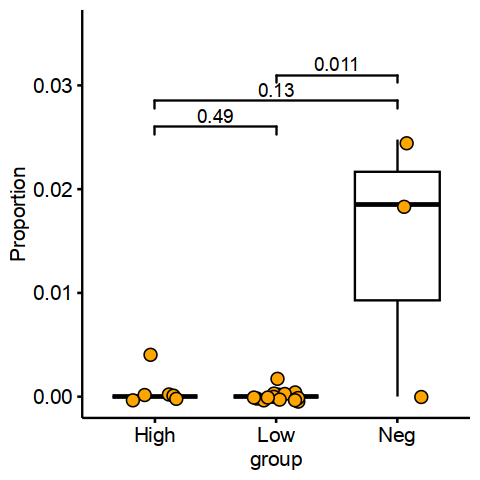

In [32]:
options(repr.plot.height=4,repr.plot.width=4)
rlt_pdcd1$p2

Warning message in wilcox.test.default(c(0, 0, 0.0319148936170213, 0, 0, 0), c(0.00250941028858218, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.0319148936170213, 0, 0, 0), c(0.157372986369269, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00250941028858218, 0, 0.00227790432801822, :
“cannot compute exact p-value with ties”


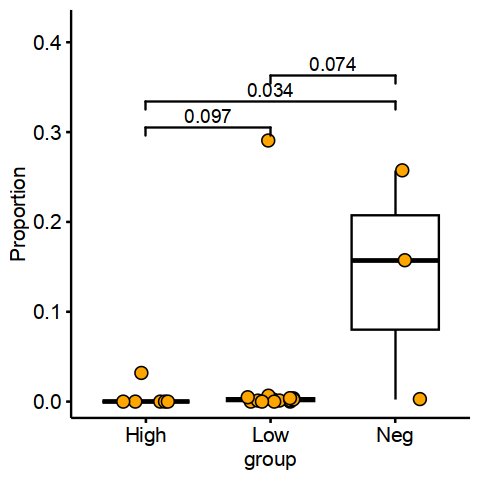

In [33]:
options(repr.plot.height=4,repr.plot.width=4)
rlt_cd47$p2

In [45]:
saveRDS(rlt_cd47$data,file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure7k.Rds")

In [28]:
options(repr.plot.height=12,repr.plot.width=12)
ggsave(plot = rlt_CD27$p1,filename = "colocalization/CD27_CD70.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_CD281$p1,filename = "colocalization/CD28_CD80.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_CD282$p1,filename = "colocalization/CD28_CD86.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_CD401$p1,filename = "colocalization/CD40_CD40LG.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_TNFSF4$p1,filename = "colocalization/TNFRSF4_TNFSF4.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_TNFSF18$p1,filename = "colocalization/TNFRSF18_TNFSF18.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_HHLA2$p1,filename = "colocalization/TMIGD2_HHLA2.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_CTLA41$p1,filename = "colocalization/CTLA4_CD80.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_CTLA42$p1,filename = "colocalization/CTLA4_CD86.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_BTLA$p1,filename = "colocalization/BTLA_TNFRSF14.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_flg1$p1,filename = "colocalization/LAG3_FGL1.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_PD1L1$p1,filename = "colocalization/PDCD1_CD274.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_TIGIT$p1,filename = "colocalization/TIGIT_PVR.colocalization.pdf",width = 12,height = 12)
ggsave(plot = rlt_cd47$p1,filename = "colocalization/CD47_SIRPA.colocalization.pdf",width = 12,height = 12)

In [32]:
ggsave(plot = rlt_pdcd1$p1,filename = "colocalization/PD1_PDL2.colocalization.pdf",width = 12,height = 12)


In [ ]:
combined_data <- do.call(rbind, lapply(ls()[str_detect(ls(), 'rlt_')], function(x) get(x)[['data']]))

In [ ]:
options(repr.plot.height=15,repr.plot.width=15)
p <- ggboxplot(combined_data, x='group', y='pct', add="jitter", add.params=list(shape=21, fill="orange", size=3)
             )+geom_signif(comparisons = list(c("High","Low"),c("High","Neg"),c("Low","Neg")),step_increase = 0.1,
                           map_signif_level = F,test = wilcox.test
                          )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.20))) +
            ylab("Proportion")+facet_wrap(~gene_pair, scale="free")

In [ ]:
options(warn = -1)

In [ ]:
options(repr.plot.height=12,repr.plot.width=12)
p

In [35]:
ggsave(filename = "colocalization_genepair_fromcell2location_cutoff1.pdf",plot = p,width = 10,height = 10)

In [ ]:
get_single_gene <- function(gene1){

    temp_data <- data2[,c(gene1),drop=FALSE]
    colnames(temp_data) <- c('gene1')
    temp_data  %>% mutate(gene1_YN = ifelse(gene1>median(gene1),'Yes','No')) -> temp_data
    temp_data  %>% rownames()  %>% GSC_merge_SCT_isct2@meta.data[.,c('group','pos')]  %>% 
            cbind(.,temp_data) -> temp_data2
    temp_data2 %>%  mutate(new = paste0(group,'_',pos))  %>% count(new,gene1_YN)  %>% 
        complete(new,gene1_YN,fill = list(n=0)) -> aa 

    aa %>% group_by(new) %>% reframe(pct=n/sum(n),new=new,gene1_YN=gene1_YN)  %>% filter(gene1_YN=='Yes') ->aa
    str_split(aa$new,'_')  %>% map_chr(first) -> aa$group
    GSC_merge_SCT_isct2_tmp <- GSC_merge_SCT_isct2

    GSC_merge_SCT_isct2_tmp@meta.data$gene1 <- temp_data2$gene1_YN
    
    my_cols <- c("Yes" = "red", "No" = "black")
    options(repr.plot.height=8,repr.plot.width=10)
    p1 <- SpatialDimPlot(GSC_merge_SCT_isct2_tmp, label = TRUE, group.by = 'gene1',label.size = 3,cols=my_cols,ncol=2)

    options(repr.plot.height=6,repr.plot.width=4)
    p2 <- ggboxplot(aa, x='group', y='pct', add="jitter", add.params=list(shape=21, fill="orange", size=3)
             )+geom_signif(comparisons = list(c("High","Low"),c("High","Neg"),c("Low","Neg")),step_increase = 0.1,map_signif_level = F,test = wilcox.test
                          )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.20))) +
            ylab("Proportion")
    return(list(p1 = p1,p2 = p2,data = aa))
}


In [ ]:
rlt_cd47 <- get_single_gene('CD47')
rlt_pdcd1 <- get_single_gene('PDCD1')
rlt_lag3 <- get_single_gene('LAG3')
rlt_CD27 <- get_single_gene('CD27')
rlt_CD28 <- get_single_gene('CD28')
rlt_CD40 <- get_single_gene('CD40')
rlt_TNFRSF9 <- get_single_gene('TNFRSF9')
rlt_TNFSF4 <- get_single_gene('TNFRSF4')
rlt_TNFSF18 <- get_single_gene('TNFRSF18')
rlt_HHLA2 <- get_single_gene('TMIGD2')
rlt_CTLA4 <- get_single_gene('CTLA4')
rlt_BTLA <- get_single_gene('BTLA')
rlt_PD1L1 <- get_single_gene('PDCD1')
rlt_TIGIT <- get_single_gene('TIGIT')

In [ ]:
options(repr.plot.height=12,repr.plot.width=12)
p <- ggarrange(rlt_cd47$p2,rlt_pdcd1$p2,rlt_lag3$p2,rlt_CD27$p2,rlt_CD28$p2,rlt_CD40$p2,
          rlt_TNFRSF9$p2,rlt_TNFSF4$p2,rlt_TNFSF18$p2,rlt_HHLA2$p2,
          rlt_CTLA4$p2,rlt_BTLA$p2,rlt_PD1L1$p2,rlt_TIGIT$p2,hjust = -3,
          labels = c('CD47','PD1',"LAG3","CD27","CD28","CD40","TNFRSF9",
                     'TNFRSF4','TNFRSF18', 'TMIGD2',
                     'CTLA4','BTLA','PDCD1','TIGIT'))

In [ ]:
p

In [ ]:
rlt_SIRPA <- get_single_gene('SIRPA')
rlt_PDCD1LG2 <- get_single_gene('PDCD1LG2')
rlt_flg1 <- get_single_gene('FGL1')
rlt_CD70 <- get_single_gene('CD70')
rlt_CD80 <- get_single_gene('CD80')
rlt_CD40LG <- get_single_gene('CD40LG')
rlt_CDC37L1 <- get_single_gene('CDC37L1')
rlt_TNFSF4 <- get_single_gene('TNFSF4')
rlt_TNFSF18 <- get_single_gene('TNFSF18')
rlt_HHLA2 <- get_single_gene('HHLA2')
rlt_CD80 <- get_single_gene('CD80')
rlt_TNFRSF14 <- get_single_gene('TNFRSF14')
rlt_CD274 <- get_single_gene('CD274')
rlt_PVR <- get_single_gene('PVR')

In [ ]:
options(repr.plot.height=15,repr.plot.width=15)
p <- ggarrange(rlt_SIRPA$p2,rlt_PDCD1LG2$p2,rlt_flg1$p2,rlt_CD70$p2,rlt_CD80$p2,rlt_CD40LG$p2,
          rlt_CDC37L1$p2,rlt_TNFSF4$p2,rlt_TNFSF18$p2,rlt_HHLA2$p2,
          rlt_CD80$p2,rlt_TNFRSF14$p2,rlt_CD274$p2,rlt_PVR$p2,
          labels = c('SIRPA','PDCD1LG2',"FGL1","CD70","CD80","CD40LG","CDC37L1",
                     'TNFSF4','TNFSF18', 'HHLA2', 'CD80','TNFRSF14','CD274','PVR'))

In [ ]:
p

### cell type colocalization

In [47]:
my_cols <- c("Yes" = "red", "No" = "black")

In [48]:
GSC_merge_SCT_isct2@meta.data  %>%  filter(Macrophages>1|Monocytes>1|DendriticCells>1)  %>% 
        filter(Epi_tumor>1)%>% rownames() -> tmp_names 

In [49]:
#GSC_merge_SCT_isct2@meta.data  %>%  filter(Tcell>1)  %>% 
#        filter(Epi_tumor>1)%>% rownames() -> tmp_names 

In [50]:
GSC_merge_SCT_isct2@meta.data$colocal <- 'No'

In [51]:
GSC_merge_SCT_isct2@meta.data[tmp_names,'colocal'] <- 'Yes'

In [52]:
GSC_merge_SCT_isct2@meta.data  %>% select(pos,group,colocal)  %>% mutate(new=paste0(pos,'_',group)) -> aa

In [53]:
aa  %>% count(new,colocal)  %>%  complete(new,colocal,fill = list(n=0)) -> aa 

In [54]:
aa %>% group_by(new) %>% reframe(pct=n/sum(n),new=new,colocal=colocal)  %>% filter(colocal=='Yes') ->aa2

In [55]:
str_split(aa2$new,'_')  %>% map_chr(last) -> aa2$group

In [56]:
options(repr.plot.height=5,repr.plot.width=5)
p_celltype_colocalization <- ggboxplot(aa2, x='group', y='pct', add="jitter", add.params=list(shape=21, fill="orange", size=3)
             )+geom_signif(comparisons = list(c("High","Low"),c("High","Neg"),c("Low","Neg")),step_increase = 0.1,map_signif_level = F,test = wilcox.test
             )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.20))) + ylab("Proportion")

Warning message in wilcox.test.default(c(0.00107181136120043, 0, 0.0651595744680851, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00107181136120043, 0, 0.0651595744680851, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.00250941028858218, 0, 0.0148063781321185, :
“cannot compute exact p-value with ties”


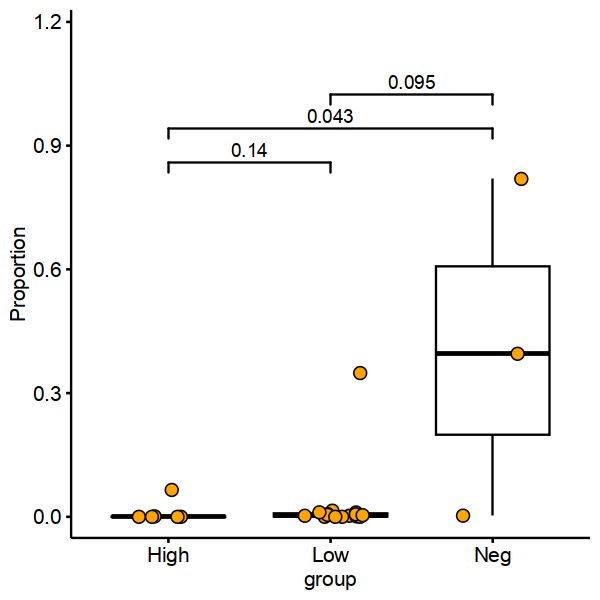

In [57]:
p_celltype_colocalization

In [58]:
saveRDS(aa2,file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure7j.Rds")

In [54]:
ggsave(filename = "Celltype_Colocalization.pdf",plot = p_celltype_colocalization,
       width = 4,height = 4)

In [59]:
options(repr.plot.height=8,repr.plot.width=10)
p_spatial <- SpatialDimPlot(GSC_merge_SCT_isct2,crop = FALSE,
                     , label = TRUE, group.by = 'colocal',label.size = 2,cols=my_cols,ncol=2)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [56]:
ggsave(filename = "Celltype_Colocalization_projection.pdf",plot = p_spatial,
       width = 10,height = 10)

In [67]:
saveRDS(GSC_merge_SCT_isct2@meta.data,file = "/disk1/pengweixing/esophageal/30.sourcedata/Suppl/Suppl.Fig35.Rds")

In [66]:
GSC_merge_SCT_isct2@meta.data

,pos,group,Bcell,DendriticCells,Endothelial,Epi_normal,Epi_tumor,Fibroblasts,Macrophages,Mastcell,Monocytes,Musclecell,NKcell,Neutrophils,Pericyte,Plasma,Tcell,colocal
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
xinpian2_AACAATCCGAGTGGAC-1,B7,Neg,0.068640076,0.199504076,0.113158181,0.596323583,3.282323039,1.077822584,3.03660009,0.13048099,0.503128022,0.069779959,0.150837716,0.240141184,0.188135450,0.300160982,3.248954391,Yes
xinpian2_AACAATGGAACCACAT-1,B4,Low,0.142163954,0.166700188,0.435283430,0.027311699,0.574888507,0.880564189,0.55253921,0.03062528,0.073483742,0.036232114,0.501234579,0.404201020,0.468479057,0.143349354,1.848549014,No
xinpian2_AACACCAGCCTACTCG-1,B1,High,0.070988409,0.029728240,0.066222918,0.447215174,9.245344257,0.004243977,0.01558887,0.01881464,0.005529788,0.003564257,0.010983291,0.008474494,0.010295882,0.030688149,0.019916131,No
xinpian2_AACACCGAGCTTGGAT-1,B4,Low,0.064065637,0.074790262,0.040890766,0.358827226,4.399531937,0.056488424,0.15877793,0.10364487,0.035587619,0.041496034,0.024037076,0.022790735,0.102833319,0.153405437,0.056856373,No
xinpian2_AACACGTTGATACCGC-1,B8,Neg,0.106495829,0.390459450,0.309888415,0.761024076,6.949097633,1.063247877,2.41259718,0.12082608,0.270782080,1.728356081,0.158807012,0.221247430,0.190192214,0.099571167,0.207285143,Yes
xinpian2_AACACTCGAAGTATCA-1,B4,Low,0.008123438,0.010622135,0.030622154,0.089788331,3.952658129,0.038273536,0.14210066,0.01720579,0.005606699,0.027595505,0.007946231,0.008311093,0.043297407,0.012576780,0.008296974,No
xinpian2_AACACTCGTGAGCTTC-1,B8,Neg,0.058324077,0.106265958,0.168160456,0.714994201,6.719570279,0.333644657,1.73430256,0.13798060,0.638470238,0.336513226,0.144553919,0.400140612,0.109041442,0.055572034,0.234314039,Yes
xinpian2_AACAGACCGCGATCTG-1,B7,Neg,1.597643828,0.647332516,1.300038207,0.051426133,0.008773344,0.490615885,0.15783707,0.08890815,0.075669886,0.014067968,0.294276099,0.763680020,0.173115184,0.332051931,2.913946843,No
xinpian2_AACAGCCTCCTGACTA-1,B8,Neg,0.063078720,0.422025134,0.457074469,1.024297011,9.073750019,1.387234318,2.47675565,0.16428577,0.121362437,0.611514422,0.072578902,0.159166011,0.510073379,0.061971434,0.173967103,Yes


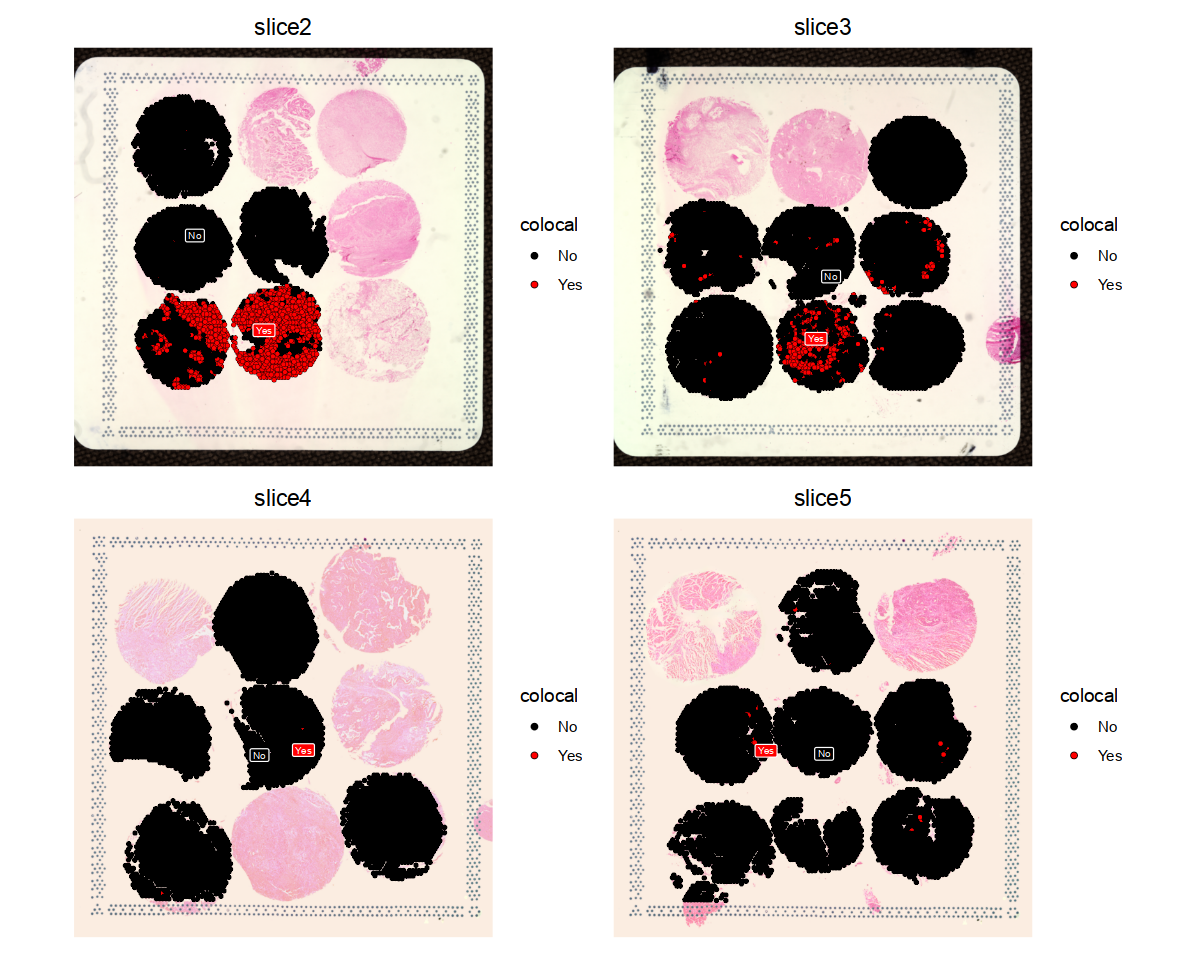

In [60]:
p_spatial

In [64]:
saveRDS(list(celltype = GSC_merge_SCT_isct2@meta.data,cd47 = rlt_cd47$data2),
        file = "/disk1/pengweixing/esophageal/30.sourcedata/Figure7i.Rds")

In [ ]:
GSC_merge_SCT_isct2@meta.data  %>% reframe(myeloid = (Monocytes+Macrophages+DendriticCells)) -> a

In [ ]:
GSC_merge_SCT_isct2$myeloid <- a$myeloid

In [ ]:
options(repr.plot.height=4,repr.plot.width=15)
p_macrophages <- SpatialFeaturePlot(GSC_merge_SCT_isct2, features = 'myeloid',
                                    max.cutoff = 6, pt.size.factor = 1.6, ncol = 4, crop = FALSE)

In [ ]:
p_macrophages <- ggrastr::rasterize(p_macrophages,dpi=300)

In [ ]:
p_macrophages

In [76]:
ggsave(filename = "Spatial_myeloid_celltype.pdf",plot = p_macrophages,width = 15,height = 4)

In [65]:
save.image('celllocation_colocalize.Rds')